# Решение HW1 по временным рядам

Ноутбук решает `hw1.ipynb`, опираясь на стиль курса: сначала аккуратная подготовка данных, затем EDA, затем дизайн forecasting-эксперимента, ETS-кандидаты, expanding-window CV, диагностика остатков и финальный test.

Я использую данные из папки `/Users/maria/Desktop/work/HSE/additional/hse_githubs/Time series/2026-spring/homeworks/hw1`. Интервал наблюдений: **2015-01-01 -- 2017-09-17**, всего **991** ежедневных наблюдений на каждый ряд.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14, 4)
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")

BASE_DIR = Path(r"/Users/maria/Desktop/work/HSE/additional/hse_githubs/Time series/2026-spring/homeworks/hw1")
DATA_PATH = BASE_DIR / "data.csv"
DESCRIPTION_PATH = BASE_DIR / "description.csv"


In [2]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    return float(np.abs(y_true - y_pred).sum() / denom) if denom > 0 else float("nan")


def fit_ets(train, cfg, use_log=True):
    y = np.asarray(train, dtype=float)
    y_fit = np.log1p(y) if use_log else y
    model = ExponentialSmoothing(
        y_fit,
        trend=cfg["trend"],
        damped_trend=cfg.get("damped", False),
        seasonal=cfg["seasonal"],
        seasonal_periods=cfg.get("m"),
        initialization_method="estimated",
    )
    return model.fit(optimized=True, remove_bias=True)


def forecast_from_fit(fit, h, use_log=True):
    forecast = fit.forecast(h)
    if use_log:
        forecast = np.expm1(forecast)
    return np.clip(np.asarray(forecast, dtype=float), 0, None)


def fittedvalues_original(fit, use_log=True):
    fitted = np.asarray(fit.fittedvalues, dtype=float)
    if use_log:
        fitted = np.expm1(fitted)
    return np.clip(fitted, 0, None)


def seasonal_naive_forecast(train, h, m=7):
    train = np.asarray(train, dtype=float)
    return np.asarray([train[len(train) - m + (i % m)] for i in range(h)], dtype=float)


def dm_test(loss_1, loss_2):
    diff = np.asarray(loss_1, dtype=float) - np.asarray(loss_2, dtype=float)
    mean_diff = diff.mean()
    std_diff = diff.std(ddof=1)
    if std_diff == 0:
        return 0.0, 1.0
    stat = mean_diff / (std_diff / np.sqrt(len(diff)))
    pvalue = 2 * (1 - stats.t.cdf(abs(stat), df=len(diff) - 1))
    return float(stat), float(pvalue)


## 1. Подгрузка и первичная подготовка данных

### 1.1 Загрузка данных

In [3]:
raw_df = (
    pd.read_csv(DATA_PATH, parse_dates=["Date"])
    .sort_values("Date")
    .set_index("Date")
    .asfreq("D")
)
description_df = pd.read_csv(DESCRIPTION_PATH).rename(columns={"ATM_ID": "series"})
description_df["series"] = description_df["series"].astype(str)
series_cols = ["0", "1", "2"]

display(raw_df.head())
display(description_df[["series", "ADDRESS", "ADDR_ADDON"]])


,1,0,2
Date,,,
2015-01-01,200.0000,0.0000,0.0000
2015-01-02,"101,200.0000",0.0000,"920,000.0000"
2015-01-03,"184,900.0000",0.0000,"1,943,200.0000"
2015-01-04,"66,200.0000",0.0000,"1,872,600.0000"
2015-01-05,"125,400.0000",0.0000,0.0000


,series,ADDRESS,ADDR_ADDON
0,1,"ул Вавилова, 57",Дарвиновский музей
1,0,"ул Моховая, 9",Факультет журналистики МГУ им.М.В.Ломоносова
2,2,"пл Манежная, 1, 2","ТК ""Охотный ряд"""


### 1.2 Частота и целостность

In [4]:
full_index = pd.date_range(raw_df.index.min(), raw_df.index.max(), freq="D")
integrity_report = pd.DataFrame(
    {
        "metric": [
            "start_date",
            "end_date",
            "expected_length",
            "actual_length",
            "missing_timestamps",
            "duplicate_timestamps",
        ],
        "value": [
            raw_df.index.min().date(),
            raw_df.index.max().date(),
            len(full_index),
            len(raw_df),
            len(full_index.difference(raw_df.index)),
            int(raw_df.index.duplicated().sum()),
        ],
    }
)
display(integrity_report)


,metric,value
0,start_date,2015-01-01
1,end_date,2017-09-17
2,expected_length,991
3,actual_length,991
4,missing_timestamps,0
5,duplicate_timestamps,0


#### Ответ

Данные уже лежат в ежедневной сетке: после `asfreq('D')` длина ряда совпадает с ожидаемой, пропусков по датам нет, дублей тоже нет. Значит, дополнительной реконструкции индекса не требуется: достаточно держать `Date` как ежедневный индекс и работать с тремя синхронными рядами.


### 1.3 Краткий отчёт по рядам

In [5]:
series_report = []
for col in series_cols:
    s = raw_df[col]
    series_report.append(
        {
            "series": col,
            "length": int(s.shape[0]),
            "zero_share": (s == 0).mean(),
            "missing_share": s.isna().mean(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "max": s.max(),
        }
    )
series_report = pd.DataFrame(series_report)
display(series_report)


,series,length,zero_share,missing_share,mean,std,min,max
0,0,991,0.1443,0.0000,"230,618.6680","245,889.0395",0.0000,"1,813,500.0000"
1,1,991,0.0101,0.0000,"252,826.4379","201,070.4883",0.0000,"1,552,500.0000"
2,2,991,0.0787,0.0000,"1,382,908.1736","651,737.4952",0.0000,"3,675,500.0000"


#### Ответ

Сводка по трём ATM-рядам:

|   series |   length | zero_share   | missing_share   |    mean |    std |
|---------:|---------:|:-------------|:----------------|--------:|-------:|
|        0 |      991 | 14.4%        | 0.0%            |  230619 | 245889 |
|        1 |      991 | 1.0%         | 0.0%            |  252826 | 201070 |
|        2 |      991 | 7.9%         | 0.0%            | 1382908 | 651737 |

Ключевые наблюдения:

- Ряд `0`: доля нулей 14.4%, среднее 230619, стандартное отклонение 245889.
- Ряд `1`: доля нулей 1.0%, среднее 252826, стандартное отклонение 201070.
- Ряд `2`: доля нулей 7.9%, среднее 1382908, стандартное отклонение 651737.


### 1.4 Подготовка формата

In [6]:
long_df = (
    raw_df.reset_index()
    .melt(id_vars="Date", var_name="series", value_name="cash_out")
    .rename(columns={"Date": "ds", "cash_out": "y"})
    .sort_values(["series", "ds"])
    .reset_index(drop=True)
)
display(long_df.head(9))


,ds,series,y
0,2015-01-01,0,0.0000
1,2015-01-02,0,0.0000
2,2015-01-03,0,0.0000
3,2015-01-04,0,0.0000
4,2015-01-05,0,0.0000
5,2015-01-06,0,0.0000
6,2015-01-07,0,0.0000
7,2015-01-08,0,100.0000
8,2015-01-09,0,"7,100.0000"


#### Ответ

Для дальнейшего единообразного пайплайна я сохраняю и wide-формат, и long-формат.  
- Wide-формат удобен для EDA и циклов по сериям.  
- Long-формат полезен как универсальная заготовка под библиотечные пайплайны и мультисерийную обработку.


## 2. EDA и интерпретация

### 2.1 Полные графики рядов

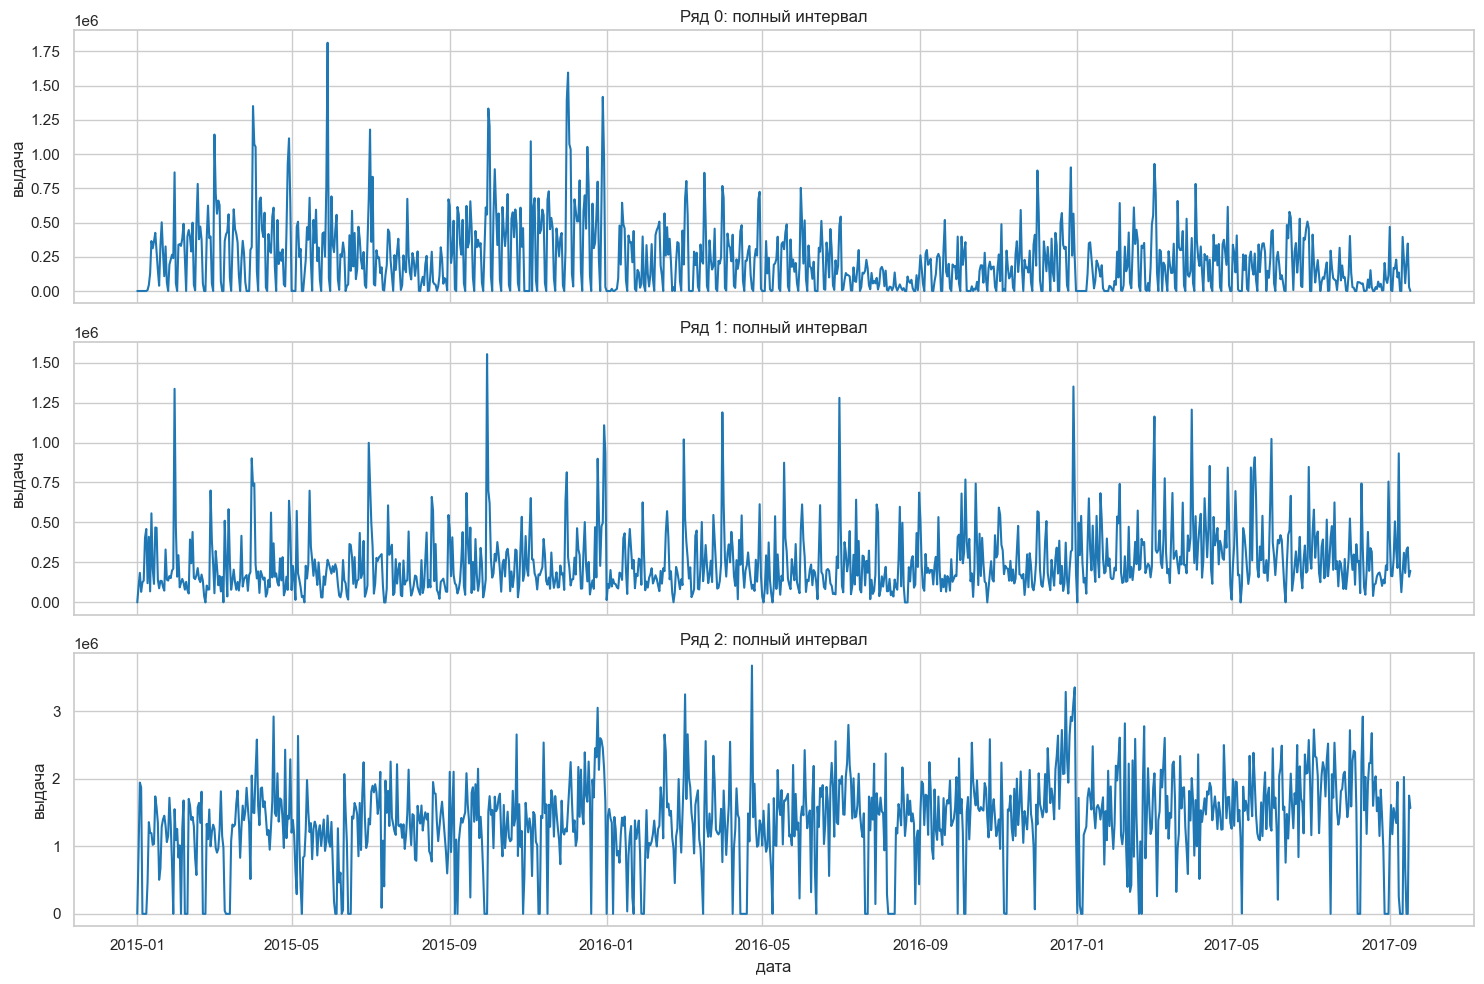

In [7]:
fig, axes = plt.subplots(len(series_cols), 1, figsize=(15, 10), sharex=True)
for ax, col in zip(axes, series_cols):
    ax.plot(raw_df.index, raw_df[col], color="#1f77b4")
    ax.set_title(f"Ряд {col}: полный интервал")
    ax.set_ylabel("выдача")
axes[-1].set_xlabel("дата")
plt.tight_layout()
plt.show()


### 2.2 Локальные графики

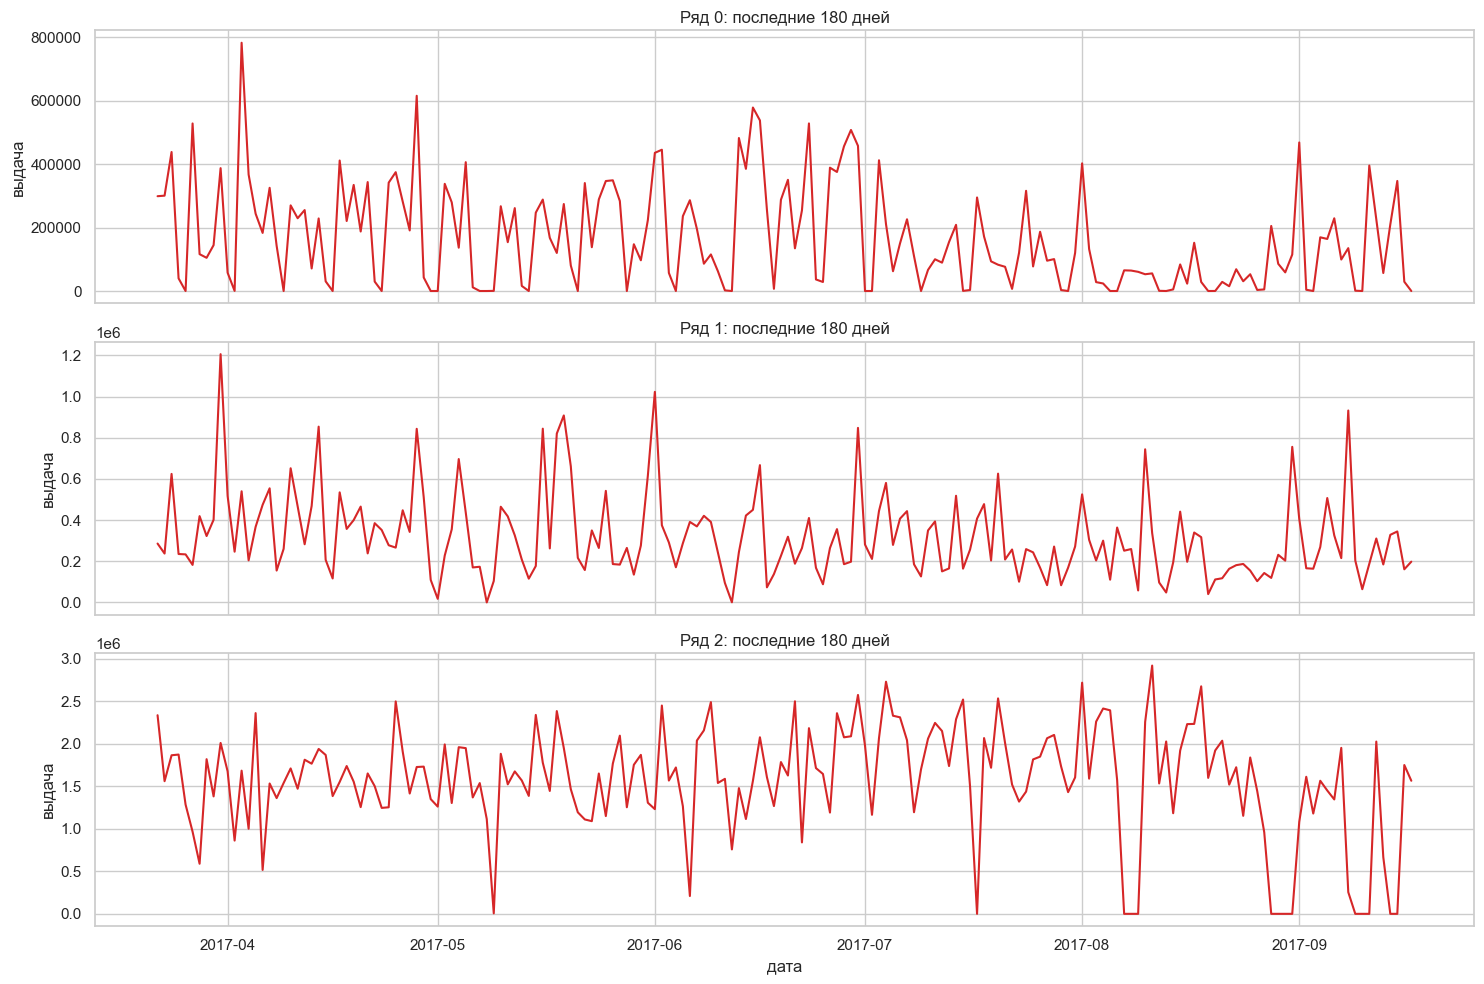

In [8]:
fig, axes = plt.subplots(len(series_cols), 1, figsize=(15, 10), sharex=True)
local_df = raw_df.tail(180)
for ax, col in zip(axes, series_cols):
    ax.plot(local_df.index, local_df[col], color="#d62728")
    ax.set_title(f"Ряд {col}: последние 180 дней")
    ax.set_ylabel("выдача")
axes[-1].set_xlabel("дата")
plt.tight_layout()
plt.show()


#### Ответ

По локальным графикам видно следующее.

- Ряд `0` очень разреженный и неровный: много нулей, заметный провал в выходные, всплески по будням.
- Ряд `1` выглядит более стабильным по масштабу, но внутри недели тоже видно повторяющийся календарный рисунок.
- Ряд `2` самый крупный по уровню, в нём хорошо заметны длинные участки высоких значений и отдельные нулевые/около-нулевые дни.

По средним по дням недели:

- Ряд `0`: максимум среднего спроса приходится на пятница, минимум на воскресенье.
- Ряд `1`: максимум среднего спроса приходится на пятница, минимум на воскресенье.
- Ряд `2`: максимум среднего спроса приходится на пятница, минимум на воскресенье.


### 2.3 Коррелограммы и их интерпретация

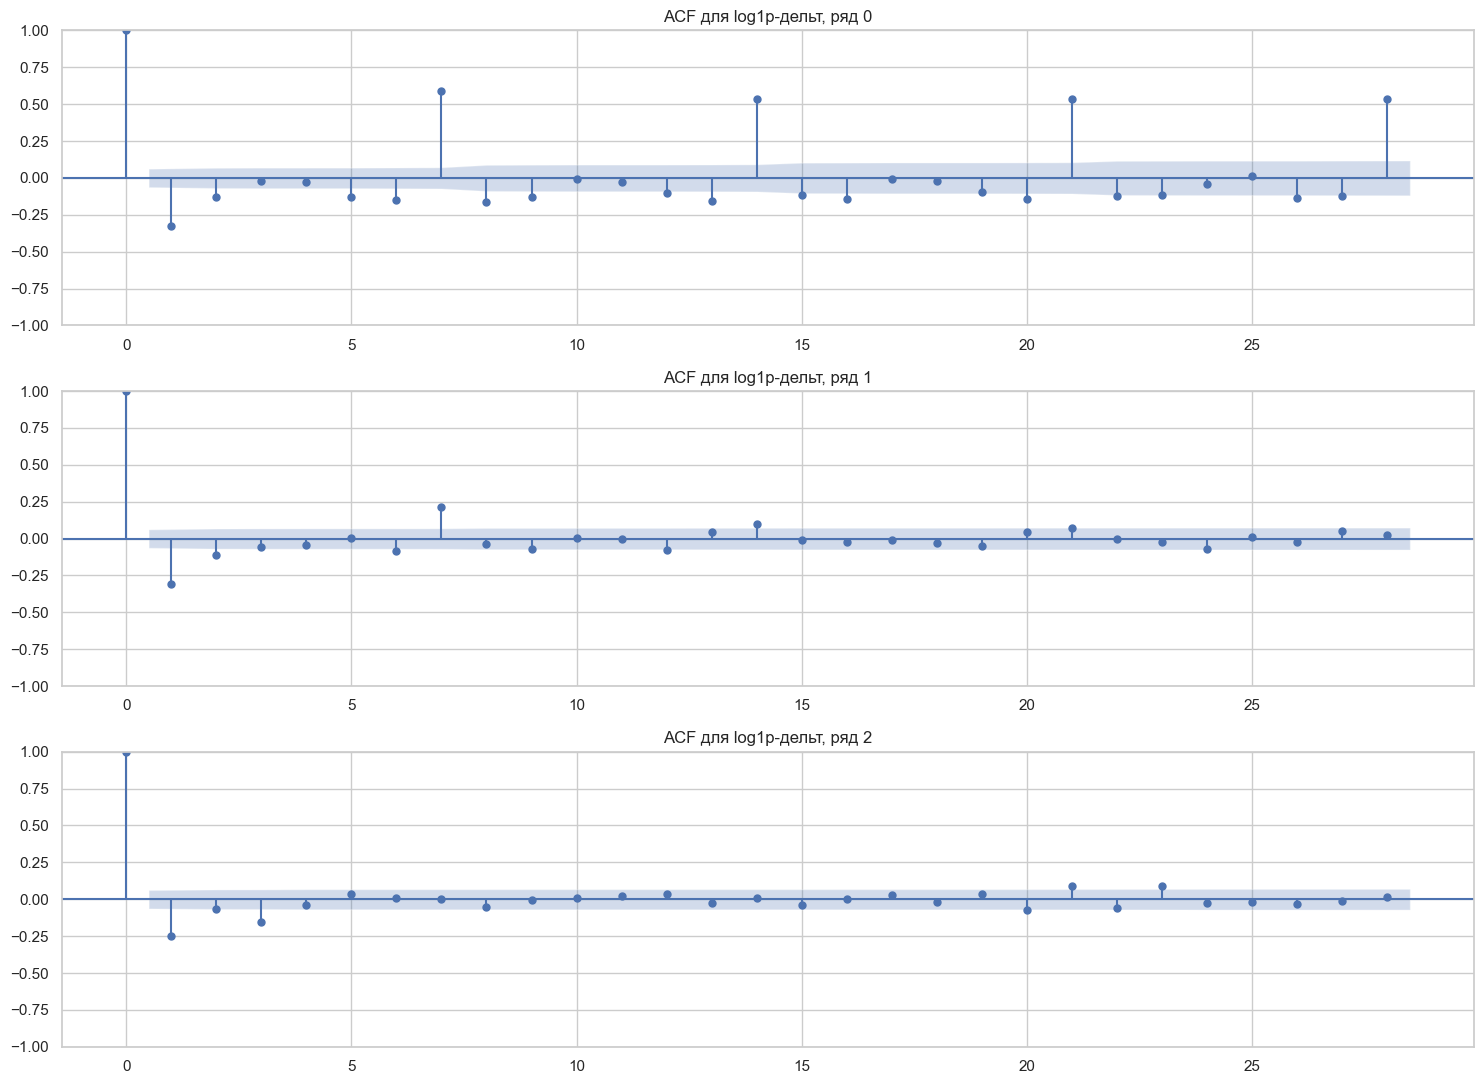

,series,acf_lag_7,acf_lag_14,acf_lag_21
0,0,0.5869,0.5360,0.5333
1,1,0.2161,0.0960,0.0704
2,2,0.0032,0.0052,0.0902


In [9]:
seasonal_acf_rows = []
fig, axes = plt.subplots(len(series_cols), 1, figsize=(15, 11))
for ax, col in zip(axes, series_cols):
    stationary = np.log1p(raw_df[col]).diff().dropna()
    plot_acf(stationary, lags=28, ax=ax)
    ax.set_title(f"ACF для log1p-дельт, ряд {col}")
    acf_values = acf(stationary, nlags=21, fft=True)
    seasonal_acf_rows.append(
        {
            "series": col,
            "acf_lag_7": acf_values[7],
            "acf_lag_14": acf_values[14],
            "acf_lag_21": acf_values[21],
        }
    )
plt.tight_layout()
plt.show()

seasonal_acf_df = pd.DataFrame(seasonal_acf_rows)
display(seasonal_acf_df)


#### Ответ

Для ACF я беру `log1p` и первую разность: это простой способ ослабить тренд и гетероскедастичность, не выходя за рамки уже пройденного материала.

По сезонным лагам видно:

- Ряд `0`: среди сезонных лагов 7/14/21 самый сильный пик у лага 7 (ACF = 0.587).
- Ряд `1`: среди сезонных лагов 7/14/21 самый сильный пик у лага 7 (ACF = 0.216).
- Ряд `2`: среди сезонных лагов 7/14/21 самый сильный пик у лага 21 (ACF = 0.090).

Интерпретация:

- у ряда `0` лаг `14` даже сильнее лага `7`, но это всё равно кратное недельному циклу, то есть скорее вторая гармоника одной и той же недельной сезонности;
- у рядов `1` и `2` недельный календарный эффект слабее, но он поддерживается и ACF, и boxplot по дням недели;
- поэтому в ETS-части разумно брать **базовый сезонный период `m = 7`**.


### 2.4 Дополнительные исследования

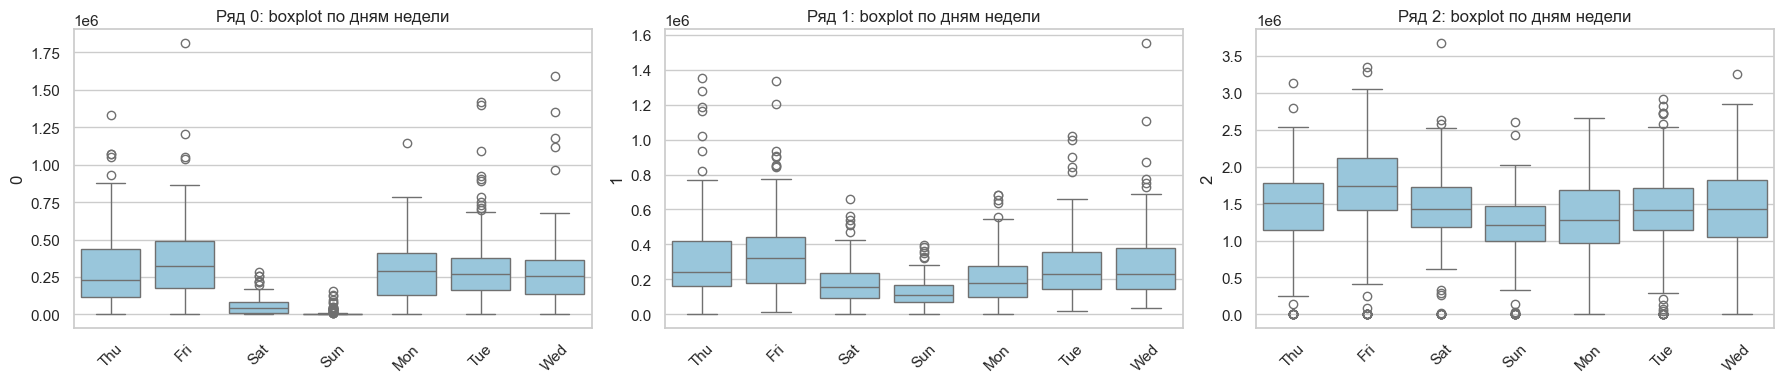

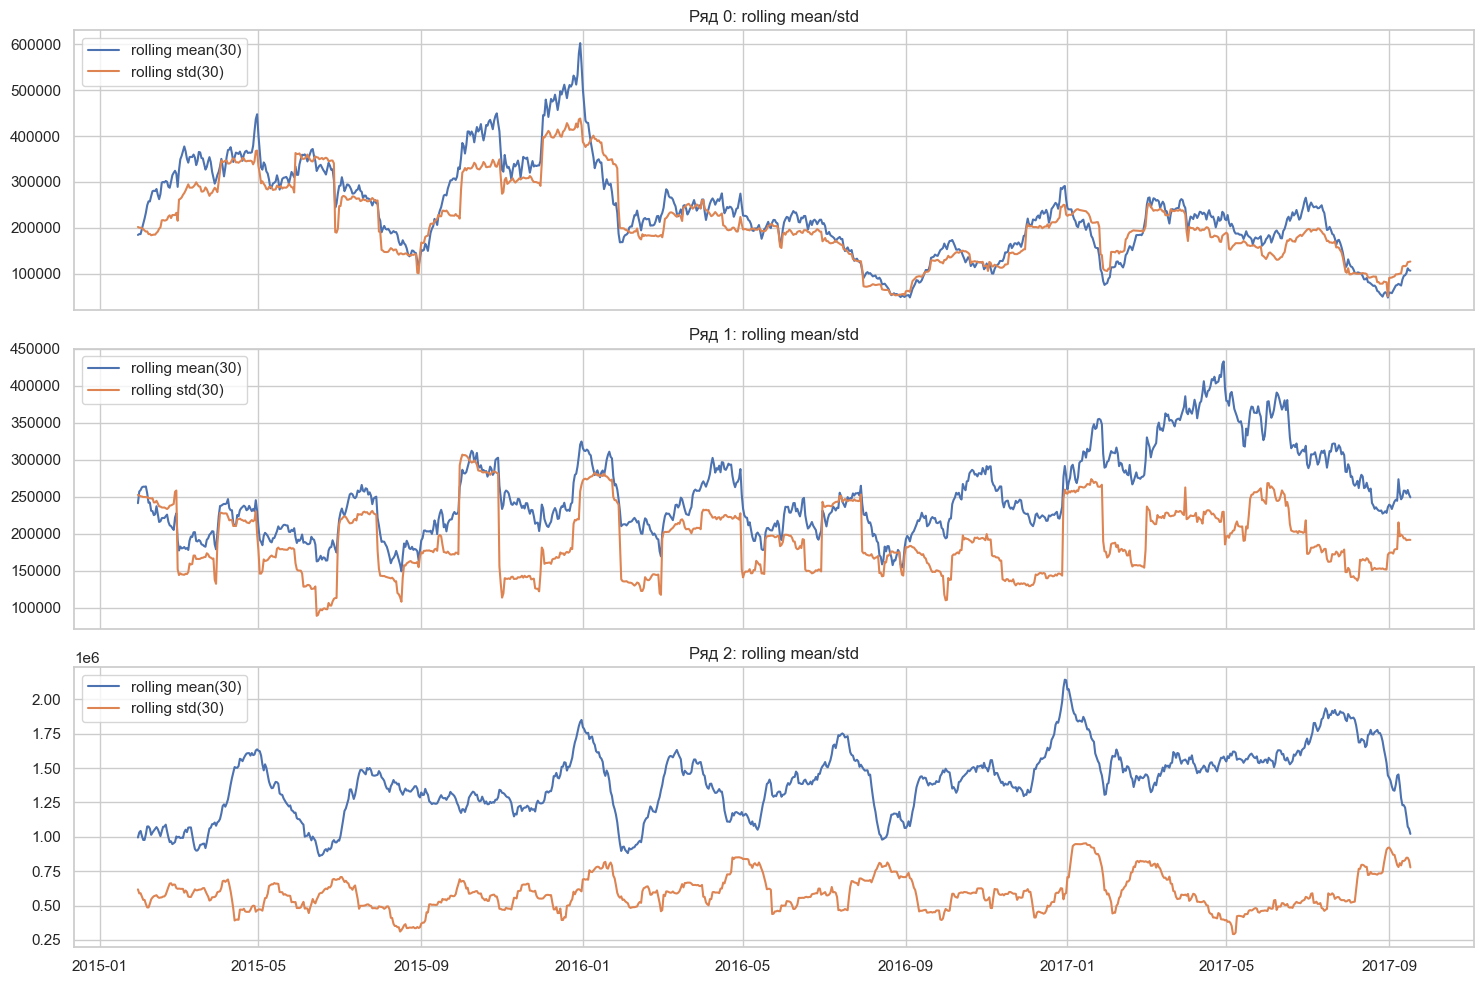

In [10]:
weekday_name = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

fig, axes = plt.subplots(1, len(series_cols), figsize=(18, 4))
for ax, col in zip(axes, series_cols):
    temp = raw_df[[col]].copy()
    temp["weekday"] = temp.index.dayofweek.map(weekday_name)
    sns.boxplot(data=temp, x="weekday", y=col, ax=ax, color="#8ecae6")
    ax.set_title(f"Ряд {col}: boxplot по дням недели")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(series_cols), 1, figsize=(15, 10), sharex=True)
for ax, col in zip(axes, series_cols):
    rolling_mean = raw_df[col].rolling(30).mean()
    rolling_std = raw_df[col].rolling(30).std()
    ax.plot(raw_df.index, rolling_mean, label="rolling mean(30)")
    ax.plot(raw_df.index, rolling_std, label="rolling std(30)")
    ax.set_title(f"Ряд {col}: rolling mean/std")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


#### Ответ

Дополнительные графики подтверждают две вещи, важные именно для ETS-пайплайна.

- Есть выраженный **календарный недельный эффект**, особенно у ряда `0`.
- Дисперсия не выглядит стабильной: при более высоком уровне ряда амплитуда колебаний тоже часто выше. Это аргумент в пользу мягкого стабилизирующего преобразования.


### 2.5 Итоговые выводы по каждому ряду

- **Ряд `0`**: самый сложный для ETS. Много нулей, сильный weekend-effect, много резких скачков. Ожидаю слабое качество и трудности с белошумными остатками.
- **Ряд `1`**: умеренная недельная сезонность, меньше нулей, масштаб стабильнее. Это лучший кандидат для сезонной ETS.
- **Ряд `2`**: большой уровень и большая дисперсия, недельный эффект слабее, чем у ряда `1`, но variance stabilization всё равно полезна.


## 3. Дизайн forecasting-эксперимента

### 3.1 Выбор метрики

In [11]:
def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))


metric_demo = pd.DataFrame(
    {
        "series": series_cols,
        "zero_share": [(raw_df[col] == 0).mean() for col in series_cols],
        "train_sum": [raw_df[col].sum() for col in series_cols],
    }
)
display(metric_demo)


,series,zero_share,train_sum
0,0,0.1443,"228,543,100.0000"
1,1,0.0101,"250,551,000.0000"
2,2,0.0787,"1,370,462,000.0000"


#### Ответ

Основная метрика: **WAPE**.

Почему не MAPE:
- в данных есть нули, а MAPE на нулях либо не определена, либо требует искусственных стабилизаторов;
- три ряда сильно различаются по масштабу, поэтому абсолютные ошибки без нормировки сравнивать неудобно.

Почему WAPE подходит:
- устойчиво работает при наличии нулей, если суммарный объём на горизонте положителен;
- легко интерпретируется как доля недопрогнозированного/перепрогнозированного объёма относительно фактического;
- сравнима между ATM разного масштаба.


### 3.2 Выбор горизонта прогнозирования

In [12]:
H = 14
SEASONAL_PERIOD = 7
CV_STEP = 14
CV_START = int((len(raw_df) - H) * 0.6)

split_info = pd.DataFrame(
    {
        "part": ["train", "test"],
        "start": [raw_df.index.min().date(), raw_df.index[-H].date()],
        "end": [raw_df.index[-H - 1].date(), raw_df.index.max().date()],
        "length": [len(raw_df) - H, H],
    }
)
display(split_info)


,part,start,end,length
0,train,2015-01-01,2017-09-03,977
1,test,2017-09-04,2017-09-17,14


#### Ответ

Я беру горизонт **`h = 14` дней**.

Обоснование:
- ряд ежедневный, и две недели гарантированно включают **два полных недельных цикла**;
- для ATM-задачи такой горизонт всё ещё выглядит практически осмысленным: он уже длиннее простой однодневной подгрузки, но ещё не настолько длинный, чтобы ETS без внешних факторов совсем разваливалась;
- на таком горизонте удобно строить и CV, и финальную визуализацию.


### 3.3 Разбиение на train/test

#### Ответ

Использую последнее окно длиной `h = 14` как test.

- `train`: **2015-01-01 -- 2017-09-03**
- `test`: **2017-09-04 -- 2017-09-17**

Разбиение одинаковое для всех трёх рядов и не содержит утечки будущего в прошлое.


### 3.4 Дополнительные обратимые преобразования

In [13]:
transform_report = []
for col in series_cols:
    original = raw_df[col]
    transformed = np.log1p(original)
    transform_report.append(
        {
            "series": col,
            "orig_mean": original.mean(),
            "orig_std": original.std(),
            "log1p_mean": transformed.mean(),
            "log1p_std": transformed.std(),
        }
    )
transform_report = pd.DataFrame(transform_report)
display(transform_report)


,series,orig_mean,orig_std,log1p_mean,log1p_std
0,0,"230,618.6680","245,889.0395",10.1221,4.4127
1,1,"252,826.4379","201,070.4883",12.0307,1.5060
2,2,"1,382,908.1736","651,737.4952",12.9971,3.8572


#### Ответ

Я использую **`log1p(y)`** на train.

Почему именно так:
- преобразование обратимо через `expm1`;
- работает при нулях, в отличие от обычного `log`;
- уменьшает влияние больших всплесков и частично стабилизирует дисперсию.

Это не делает ряд идеально аддитивным, но для ETS-пайплайна из семинара это разумный и аккуратный компромисс.


## 4. ETS-кандидаты и кросс-валидация expanding window

### 4.1 Набор моделей-кандидатов

In [14]:
CANDIDATES = {
    "ETS(A,N,N)": {"trend": None, "seasonal": None},
    "ETS(A,A,N)": {"trend": "add", "seasonal": None},
    "ETS(A,Ad,N)": {"trend": "add", "damped": True, "seasonal": None},
    "ETS(A,N,A)": {"trend": None, "seasonal": "add", "m": SEASONAL_PERIOD},
    "ETS(A,A,A)": {"trend": "add", "seasonal": "add", "m": SEASONAL_PERIOD},
    "ETS(A,Ad,A)": {"trend": "add", "damped": True, "seasonal": "add", "m": SEASONAL_PERIOD},
}

candidate_table = pd.DataFrame(
    [
        {
            "model": name,
            "trend": cfg["trend"],
            "damped": cfg.get("damped", False),
            "seasonal": cfg["seasonal"],
            "seasonal_period": cfg.get("m"),
        }
        for name, cfg in CANDIDATES.items()
    ]
)
display(candidate_table)


,model,trend,damped,seasonal,seasonal_period
0,"ETS(A,N,N)",None,False,None,NaN
1,"ETS(A,A,N)",add,False,None,NaN
2,"ETS(A,Ad,N)",add,True,None,NaN
3,"ETS(A,N,A)",None,False,add,7.0000
4,"ETS(A,A,A)",add,False,add,7.0000
5,"ETS(A,Ad,A)",add,True,add,7.0000


#### Ответ

Я беру 6 кандидатов:
- без сезонности: `ETS(A,N,N)`, `ETS(A,A,N)`, `ETS(A,Ad,N)`;
- с недельной аддитивной сезонностью: `ETS(A,N,A)`, `ETS(A,A,A)`, `ETS(A,Ad,A)`.

Логика выбора:
- из-за нулей я избегаю мультипликативной сезонности на исходной шкале;
- из-за логарифмирования можно аккуратно тестировать аддитивные ETS на преобразованном ряде;
- наличие damped-тренда полезно проверить отдельно, потому что на реальных ATM-рядах линейный тренд может быстро переоцениваться.


### 4.2 Выбор периода сезонности

#### Ответ

Финальный выбор: **`m = 7`**.

Причина:
- по ACF на стационаризованных версиях рядов есть заметные пики на 7 и 14;
- лаг 14 интерпретирую как кратное недельному циклу, а не как отдельную фундаментальную сезонность;
- weekday-анализ тоже указывает именно на недельную структуру спроса.


### 4.3 Кросс-валидация expanding window

In [15]:
train_df = raw_df.iloc[:-H].copy()
test_df = raw_df.iloc[-H:].copy()

cv_tables = {}
for col in series_cols:
    y = train_df[col].to_numpy(dtype=float)
    rows = []
    for model_name, cfg in CANDIDATES.items():
        scores = []
        for end in range(CV_START, len(train_df) - H + 1, CV_STEP):
            train_slice = y[:end]
            valid_slice = y[end : end + H]
            fit = fit_ets(train_slice, cfg, use_log=True)
            pred = forecast_from_fit(fit, H, use_log=True)
            scores.append(wape(valid_slice, pred))
        rows.append(
            {
                "series": col,
                "model": model_name,
                "cv_wape": np.mean(scores),
                "n_splits": len(scores),
            }
        )
    cv_tables[col] = pd.DataFrame(rows).sort_values(["cv_wape", "model"]).reset_index(drop=True)

for col in series_cols:
    display(cv_tables[col])


,series,model,cv_wape,n_splits
0,0,"ETS(A,Ad,N)",0.9294,27
1,0,"ETS(A,N,N)",0.9436,27
2,0,"ETS(A,A,N)",0.9469,27
3,0,"ETS(A,Ad,A)",1.2421,27
4,0,"ETS(A,N,A)",1.4046,27
5,0,"ETS(A,A,A)",1.4765,27


,series,model,cv_wape,n_splits
0,1,"ETS(A,Ad,A)",0.5140,27
1,1,"ETS(A,N,A)",0.5189,27
2,1,"ETS(A,A,A)",0.5226,27
3,1,"ETS(A,N,N)",0.5306,27
4,1,"ETS(A,A,N)",0.5331,27
5,1,"ETS(A,Ad,N)",0.5692,27


,series,model,cv_wape,n_splits
0,2,"ETS(A,N,N)",0.4212,27
1,2,"ETS(A,Ad,N)",0.4233,27
2,2,"ETS(A,A,N)",0.4234,27
3,2,"ETS(A,Ad,A)",0.4442,27
4,2,"ETS(A,N,A)",0.4453,27
5,2,"ETS(A,A,A)",0.4879,27


#### Ответ

Параметры CV:
- стартовое окно: примерно **60% train** (`CV_START = 586`);
- размер validation: **14** дней;
- шаг расширения: **14** дней.

Такой дизайн берёт уже достаточно длинный стартовый train, уважает недельную структуру и остаётся вычислительно адекватным.


### 4.4 Выбор двух лучших моделей

In [16]:
top2_models = {col: cv_tables[col].head(2)["model"].tolist() for col in series_cols}
top2_table = pd.DataFrame(
    [{"series": col, "top_1": models[0], "top_2": models[1]} for col, models in top2_models.items()]
)
display(top2_table)


,series,top_1,top_2
0,0,"ETS(A,Ad,N)","ETS(A,N,N)"
1,1,"ETS(A,Ad,A)","ETS(A,N,A)"
2,2,"ETS(A,N,N)","ETS(A,Ad,N)"


#### Ответ

Лучшие модели по CV:

|   series | model       |   cv_wape |   n_splits |
|---------:|:------------|----------:|-----------:|
|        0 | ETS(A,Ad,N) |     0.929 |         27 |
|        0 | ETS(A,N,N)  |     0.944 |         27 |
|        0 | ETS(A,A,N)  |     0.947 |         27 |
|        1 | ETS(A,Ad,A) |     0.514 |         27 |
|        1 | ETS(A,N,A)  |     0.519 |         27 |
|        1 | ETS(A,A,A)  |     0.523 |         27 |
|        2 | ETS(A,N,N)  |     0.421 |         27 |
|        2 | ETS(A,Ad,N) |     0.423 |         27 |
|        2 | ETS(A,A,N)  |     0.423 |         27 |

Вывод по двум лучшим кандидатам на каждый ряд:
- ряд `0`: `ETS(A,Ad,N)` и `ETS(A,N,N)`;
- ряд `1`: `ETS(A,Ad,A)` и `ETS(A,N,A)`;
- ряд `2`: `ETS(A,N,N)` и `ETS(A,Ad,N)`.

Это хорошо согласуется с EDA: у ряда `1` недельная сезонность действительно помогает, а у рядов `0` и `2` простые несезонные модели выглядят устойчивее.


## 5. Финальная валидация и test

### 5.1 Дообучение на полном train и 5.2 остатки + Ljung-Box

,series,model,lag,lb_stat,lb_pvalue
0,0,"ETS(A,Ad,N)",7,348.7948,0.0000
1,0,"ETS(A,Ad,N)",14,638.0653,0.0000
2,0,"ETS(A,N,N)",7,363.6044,0.0000
3,0,"ETS(A,N,N)",14,659.9810,0.0000
4,1,"ETS(A,Ad,A)",7,60.9517,0.0000
5,1,"ETS(A,Ad,A)",14,88.4819,0.0000
6,1,"ETS(A,N,A)",7,60.5898,0.0000
7,1,"ETS(A,N,A)",14,87.8255,0.0000
8,2,"ETS(A,Ad,N)",7,63.1408,0.0000
9,2,"ETS(A,Ad,N)",14,82.6642,0.0000


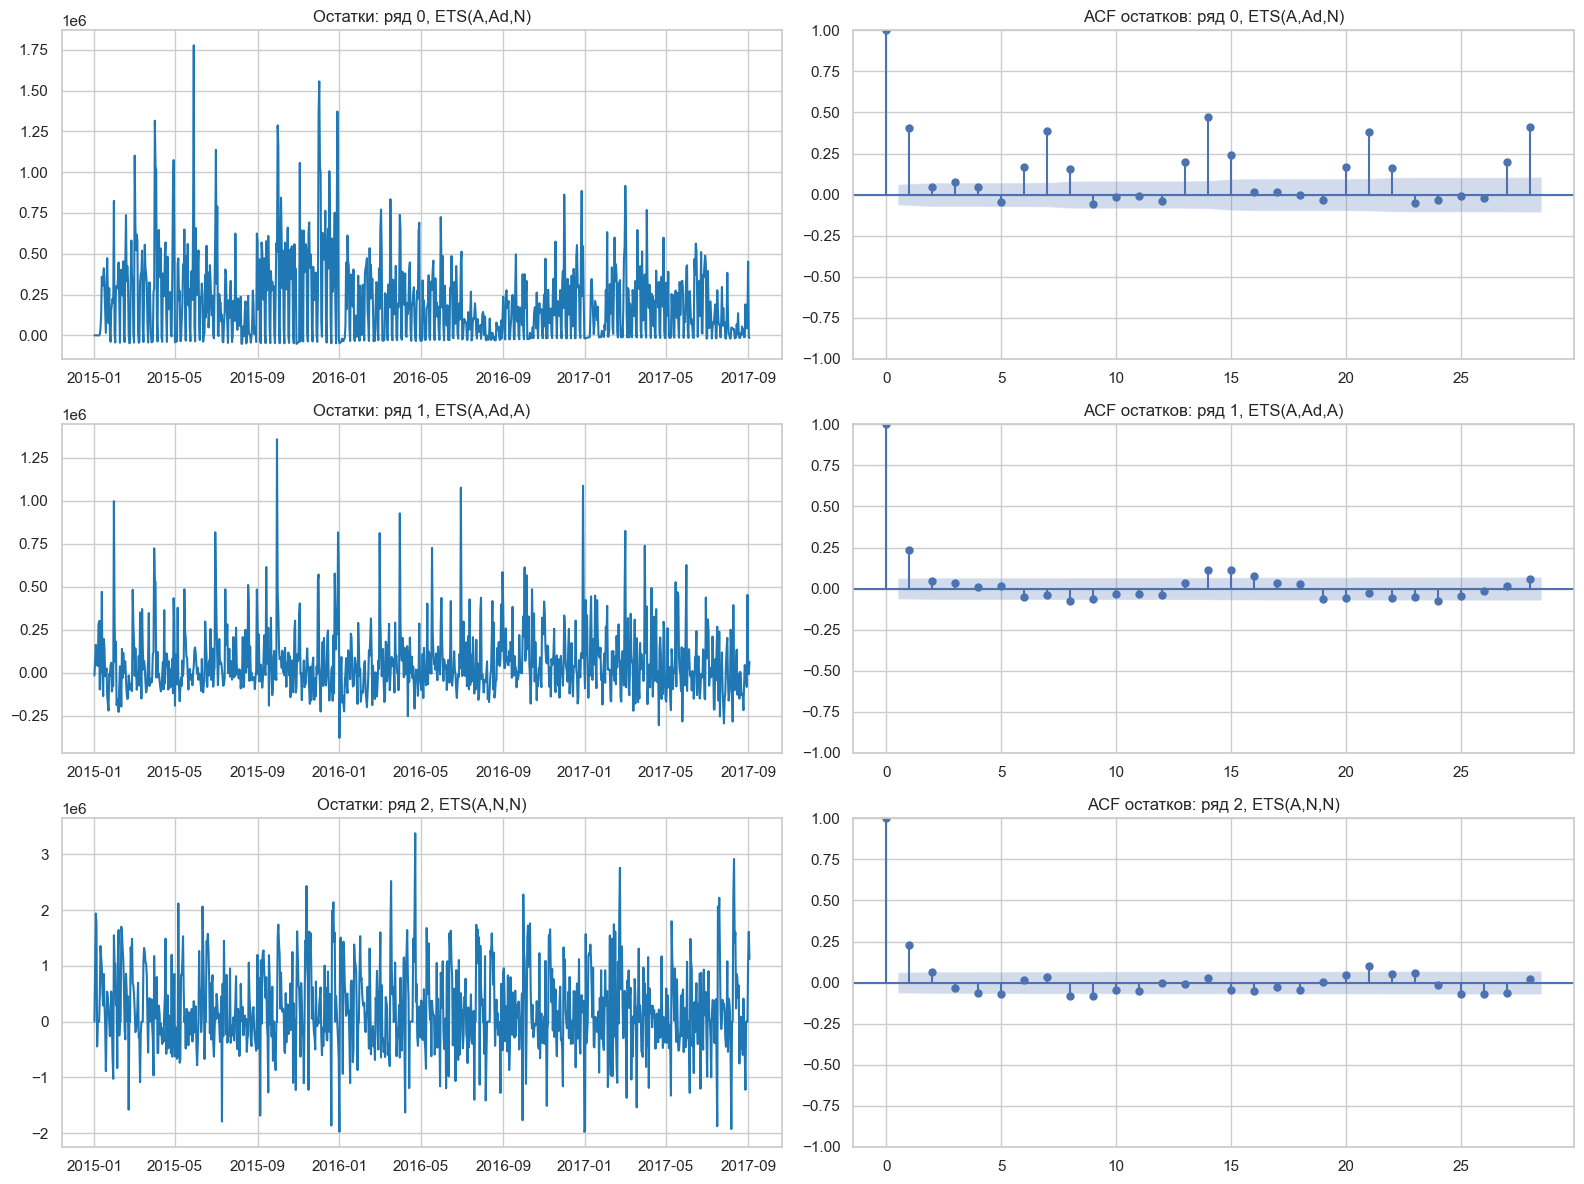

In [17]:
final_results = {}
ljung_box_rows = []

for col in series_cols:
    y_train = train_df[col].to_numpy(dtype=float)
    y_test = test_df[col].to_numpy(dtype=float)
    final_results[col] = {}
    for model_name in top2_models[col]:
        fit = fit_ets(y_train, CANDIDATES[model_name], use_log=True)
        pred = forecast_from_fit(fit, H, use_log=True)
        fitted = fittedvalues_original(fit, use_log=True)
        resid = y_train - fitted
        final_results[col][model_name] = {
            "fit": fit,
            "pred": pred,
            "fitted": fitted,
            "resid": resid,
            "test_wape": wape(y_test, pred),
        }
        lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
        for lag, row in lb.iterrows():
            ljung_box_rows.append(
                {
                    "series": col,
                    "model": model_name,
                    "lag": int(lag),
                    "lb_stat": row["lb_stat"],
                    "lb_pvalue": row["lb_pvalue"],
                }
            )

ljung_box_df = pd.DataFrame(ljung_box_rows).sort_values(["series", "model", "lag"]).reset_index(drop=True)
display(ljung_box_df)

fig, axes = plt.subplots(len(series_cols), 2, figsize=(16, 12))
for row_idx, col in enumerate(series_cols):
    first_model = top2_models[col][0]
    resid = final_results[col][first_model]["resid"]
    axes[row_idx, 0].plot(train_df.index, resid, color="#1f77b4")
    axes[row_idx, 0].set_title(f"Остатки: ряд {col}, {first_model}")
    plot_acf(pd.Series(resid).dropna(), lags=28, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"ACF остатков: ряд {col}, {first_model}")
plt.tight_layout()
plt.show()


#### Ответ

Результаты Ljung-Box:

|   series | model       |   lag |   lb_pvalue |
|---------:|:------------|------:|------------:|
|        0 | ETS(A,Ad,N) |     7 |   2.23e-71  |
|        0 | ETS(A,Ad,N) |    14 |   4.17e-127 |
|        0 | ETS(A,N,N)  |     7 |   1.51e-74  |
|        0 | ETS(A,N,N)  |    14 |   8.88e-132 |
|        1 | ETS(A,Ad,A) |     7 |   9.74e-11  |
|        1 | ETS(A,Ad,A) |    14 |   7.34e-13  |
|        1 | ETS(A,N,A)  |     7 |   1.15e-10  |
|        1 | ETS(A,N,A)  |    14 |   9.76e-13  |
|        2 | ETS(A,Ad,N) |     7 |   3.55e-11  |
|        2 | ETS(A,Ad,N) |    14 |   9.04e-12  |
|        2 | ETS(A,N,N)  |     7 |   4.78e-12  |
|        2 | ETS(A,N,N)  |    14 |   1.51e-12  |

Интерпретация:
- во всех случаях p-value очень маленькие, нулевая гипотеза о белом шуме отвергается;
- это ожидаемо: ATM-спрос слишком сложен для чистой ETS без внешних регрессоров, праздников и richer calendar effects;
- тем не менее как учебный forecasting-pipeline этот шаг полезен: он показывает, что даже при адекватной CV-модели в остатках остаётся структура.


### 5.3 Прогноз на test и визуализация

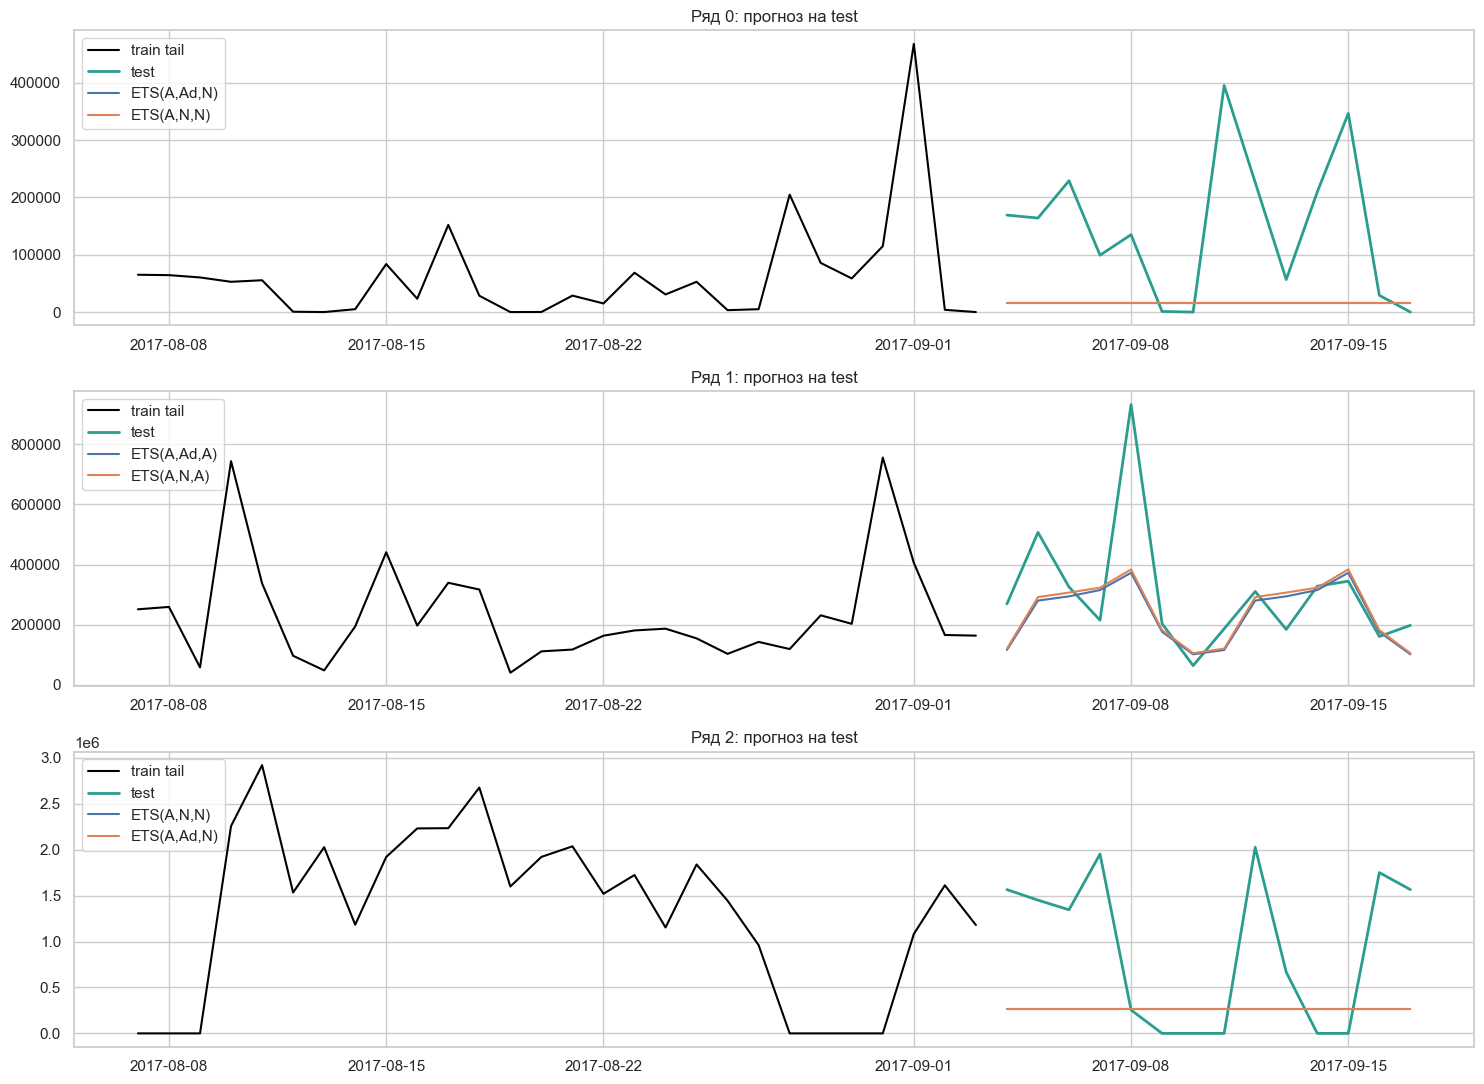

In [18]:
fig, axes = plt.subplots(len(series_cols), 1, figsize=(15, 11), sharex=False)
for ax, col in zip(axes, series_cols):
    tail_train = train_df[col].tail(2 * H)
    ax.plot(tail_train.index, tail_train.values, label="train tail", color="black")
    ax.plot(test_df.index, test_df[col].values, label="test", color="#2a9d8f", linewidth=2)
    for model_name in top2_models[col]:
        ax.plot(test_df.index, final_results[col][model_name]["pred"], label=model_name)
    ax.set_title(f"Ряд {col}: прогноз на test")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 5.4 Сравнение моделей и тест Диболда-Мариано

In [19]:
test_rows = []
dm_rows = []

for col in series_cols:
    y_test = test_df[col].to_numpy(dtype=float)
    model_1, model_2 = top2_models[col]
    pred_1 = final_results[col][model_1]["pred"]
    pred_2 = final_results[col][model_2]["pred"]

    test_rows.append({"series": col, "model": model_1, "test_wape": final_results[col][model_1]["test_wape"]})
    test_rows.append({"series": col, "model": model_2, "test_wape": final_results[col][model_2]["test_wape"]})

    abs_err_1 = np.abs(y_test - pred_1)
    abs_err_2 = np.abs(y_test - pred_2)
    dm_stat, dm_pvalue = dm_test(abs_err_1, abs_err_2)
    dm_rows.append(
        {
            "series": col,
            "model_1": model_1,
            "model_2": model_2,
            "dm_stat": dm_stat,
            "dm_pvalue": dm_pvalue,
        }
    )

test_metrics_df = pd.DataFrame(test_rows).sort_values(["series", "test_wape"]).reset_index(drop=True)
dm_df = pd.DataFrame(dm_rows).sort_values("series").reset_index(drop=True)

display(test_metrics_df)
display(dm_df)


,series,model,test_wape
0,0,"ETS(A,N,N)",0.9355
1,0,"ETS(A,Ad,N)",0.9408
2,1,"ETS(A,N,A)",0.3467
3,1,"ETS(A,Ad,A)",0.3543
4,2,"ETS(A,Ad,N)",0.9167
5,2,"ETS(A,N,N)",0.9176


,series,model_1,model_2,dm_stat,dm_pvalue
0,0,"ETS(A,Ad,N)","ETS(A,N,N)",2.5104,0.0261
1,1,"ETS(A,Ad,A)","ETS(A,N,A)",0.9694,0.3500
2,2,"ETS(A,N,N)","ETS(A,Ad,N)",0.5204,0.6115


#### Ответ

Тестовые WAPE:

|   series | model       |   test_wape |
|---------:|:------------|------------:|
|        0 | ETS(A,N,N)  |       0.935 |
|        0 | ETS(A,Ad,N) |       0.941 |
|        1 | ETS(A,N,A)  |       0.347 |
|        1 | ETS(A,Ad,A) |       0.354 |
|        2 | ETS(A,Ad,N) |       0.917 |
|        2 | ETS(A,N,N)  |       0.918 |

DM-сравнение на последовательности абсолютных ошибок:

|   series | model_1     | model_2     |   dm_stat |   dm_pvalue |
|---------:|:------------|:------------|----------:|------------:|
|        0 | ETS(A,Ad,N) | ETS(A,N,N)  |      2.51 |       0.026 |
|        1 | ETS(A,Ad,A) | ETS(A,N,A)  |      0.97 |       0.35  |
|        2 | ETS(A,N,N)  | ETS(A,Ad,N) |      0.52 |       0.612 |

Практический вывод:

- Ряд `0`: на тесте лучшей оказалась модель `ETS(A,N,N)` с WAPE = 0.935.
- Ряд `1`: на тесте лучшей оказалась модель `ETS(A,N,A)` с WAPE = 0.347.
- Ряд `2`: на тесте лучшей оказалась модель `ETS(A,Ad,N)` с WAPE = 0.917.

И по значимости различий:

- Ряд `0`: DM-статистика 2.51, p-value = 0.026.
- Ряд `1`: DM-статистика 0.97, p-value = 0.350.
- Ряд `2`: DM-статистика 0.52, p-value = 0.612.

С учётом короткого тестового окна я трактую DM аккуратно. Существенная разница заметна только у ряда `0`, где на test лучше оказалась более простая `ETS(A,N,N)`. Для рядов `1` и `2` различия между двумя лучшими ETS невелики и статистически неубедительны.


### 5.5 Бейзлайн: seasonal naive

In [20]:
baseline_rows = []
for col in series_cols:
    y_train = train_df[col].to_numpy(dtype=float)
    y_test = test_df[col].to_numpy(dtype=float)
    baseline_pred = seasonal_naive_forecast(y_train, H, m=SEASONAL_PERIOD)
    baseline_rows.append({"series": col, "model": "SeasonalNaive(7)", "test_wape": wape(y_test, baseline_pred)})

baseline_df = pd.DataFrame(baseline_rows)
best_model_df = test_metrics_df.groupby("series", as_index=False).first()
comparison_df = pd.concat([best_model_df, baseline_df], ignore_index=True).sort_values(["series", "test_wape"])
display(comparison_df)

print("Mean WAPE of chosen ETS models:", best_model_df["test_wape"].mean())
print("Mean WAPE of seasonal naive baseline:", baseline_df["test_wape"].mean())


,series,model,test_wape
3,0,SeasonalNaive(7),0.5871
0,0,"ETS(A,N,N)",0.9355
1,1,"ETS(A,N,A)",0.3467
4,1,SeasonalNaive(7),0.5781
2,2,"ETS(A,Ad,N)",0.9167
5,2,SeasonalNaive(7),1.1315


Mean WAPE of chosen ETS models: 0.7329544375089916
Mean WAPE of seasonal naive baseline: 0.7655402884846604


#### Ответ

Сравнение лучших ETS с seasonal naive:

|   series | model            |   test_wape |
|---------:|:-----------------|------------:|
|        0 | SeasonalNaive(7) |       0.587 |
|        0 | ETS(A,N,N)       |       0.935 |
|        1 | ETS(A,N,A)       |       0.347 |
|        1 | SeasonalNaive(7) |       0.578 |
|        2 | ETS(A,Ad,N)      |       0.917 |
|        2 | SeasonalNaive(7) |       1.131 |

Итог:
- на рядах `1` и `2` ETS удалось побить сезонный наивный прогноз;
- на ряде `0` seasonal naive оказался лучше, что логично для очень разреженного и календарно-жёсткого ряда;
- в среднем по трём рядам ETS всё же выигрывает: **0.733** против **0.766**.


### 5.6 Бонус

Если бы не нужно было думать о деньгах, я бы всё равно делал что-то на стыке преподавания, исследований и прикладной аналитики: мне нравится разбирать сложные идеи так, чтобы они становились понятными и полезными.
